# Normalize Total Gradient (NTG) - From the Scratch (v1)

### Importamos las librerías necesarias para calcular el NTG

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

### Cargamos las imágenes

In [2]:
ti = 1 # Definimos el total de imagenes a trabajar

## -- Inicialización de listas para almacenar las imagenes -- ##

img_BGR = []                # Lista de imagenes BGR (formato base)
img_IR = []                 # Lista de imagenes NIR (espectro IR)
img_RGB = []                # Lista de imagenes RGB (conversión para visualización de color apropiada)
img_RGBgray = []            # Lista de imagenes RGB en grayscale (usado para aplicar operaciones)
img_IR_translation = []     # Lista de imagenes NIR con aberraciones (traslación)

## -- Carga de imagenes del dataset y operaciones sobre ellas (aberraciones,conversiones,etc.) -- ## {n:03d}
for n in range(1):
    bgr = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Sat_images/Photos_2018/GC_019.png')
    ir = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Additional_data/Infrared_images/Infrared_2018/GC_019_Infrarred.png',cv2.IMREAD_GRAYSCALE)

    # Verificación de carga correcta de imagenes
    if bgr is None or ir is None:
        print(f'Error al cargar la imagen {n}')
        continue

    ## -- Conversiones de formato -- ##
    rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)          # Conversión de BGR a RGB
    rgb_gray = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)    # Conversión de RGB a Grayscale

    
    ## -- ABERRACIÓN - imagen IR desplazada (en x, y o ambas) -- ##
    h_ir, w_ir = ir.shape[:2]                                    # Obtenemos las dimensiones de la imagen

    tras_x = 200                                                 # Pixeles de desplazamiento en x (+ derecha, - izquierda)
    tras_y = 200                                                 # Pixeles de desplazamiento en y (+ abajo, - arriba)
    m_translation = np.float32([[1,0,tras_x],[0,1,tras_y]])      # Matriz de traslación 

    translation_imgIR = cv2.warpAffine(ir,m_translation,(w_ir,h_ir)) # Generamos la imagen con traslación

    # -- Guardar la imagenes en sus respectivas listas -- ##
    img_BGR.append(bgr)                            # Agregar las imagenes BGR a la lista
    img_RGB.append(rgb)                            # Agregar las imagenes RGB a la lista
    img_IR.append(ir)                              # Agregar las imagenes NIR a la lista
    img_RGBgray.append(rgb_gray)                   # Agregar las imagenes RGB en grayscale a la lista
    img_IR_translation.append(translation_imgIR)   # Agregar las imagenes NIR con traslación a la lista

(982, 1964)


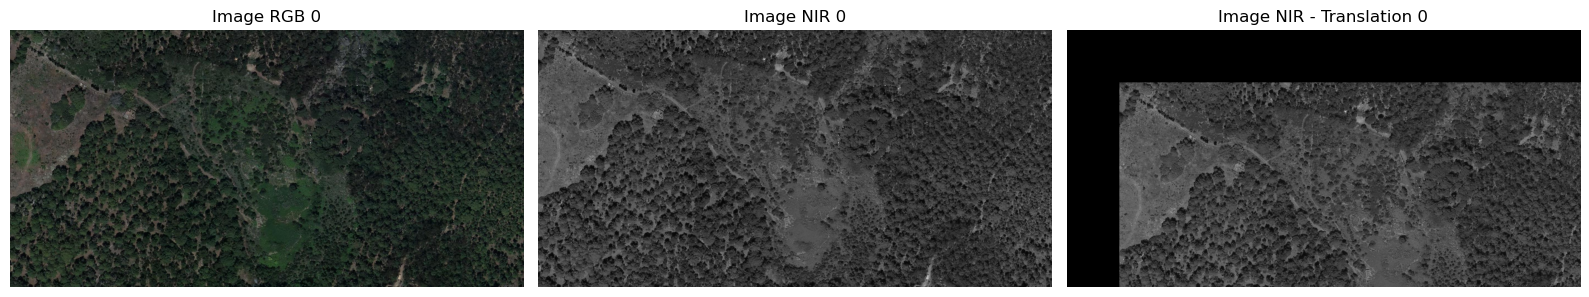

In [3]:
for n in range(len(img_RGB)):
    plt.figure(figsize=(16,14))
    
    plt.subplot(1,3,1)
    plt.title(f"Image RGB {n}")
    plt.imshow(img_RGB[n])
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title(f"Image NIR {n}")
    plt.imshow(img_IR[n],cmap='gray')
    plt.axis('off')
    print(img_RGBgray[n].shape)

    plt.subplot(1,3,3)
    plt.title(f"Image NIR - Translation {n}")
    plt.imshow(img_IR_translation[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## NTG - Versión I [versión base aproximada al paper de Cheng]

### Step I - Normalización

In [4]:
## === FUNCIÓN DE NORMALIZACIÓN PARA NTG === ##
def normalize_image(img):
    
    img = img.astype(np.float32)    # Conversión del tipo de dato a float de 32 bits

    min_val = np.min(img)           # Valores mínimos de la imagen normalizada
    max_val = np.max(img)           # Valores máximos de la imagen normalizada

    if max_val - min_val < 1e-8:    # Control para evitar divisiones entre 0 y con ello errores
        return np.zeros_like(img)

    norm_img = (img - min_val)/(max_val - min_val)  # Normalizamos la intensidad de la imagen
    
    return norm_img

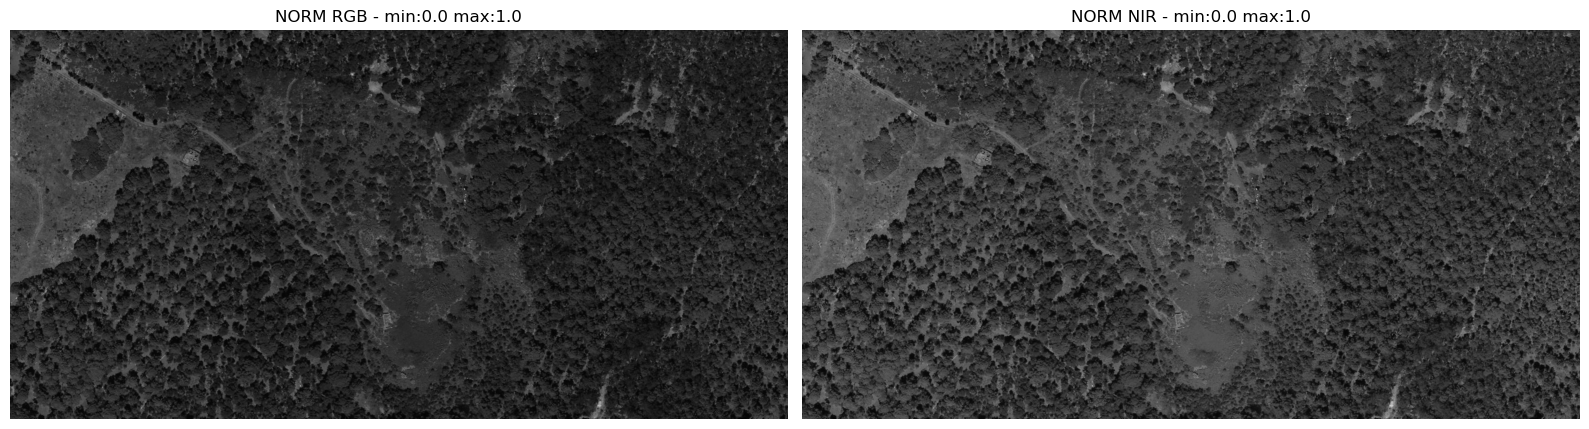

In [5]:
## -- Listas para guardar las imagenes normalizadas -- ##

normRGB_list = []     # Lista para imágenes RGB normalizadas
normNIR_list = []     # Lista para imágener NIR normalizadas 


for n in range(len(img_RGB)):

    ## --- Normalización --- ##
    
    norm_RGB = normalize_image(img_RGBgray[n])    # Normalizamos la imagen RGB
    norm_NIR = normalize_image(img_IR[n])    # Normalizamos la imagen NIR

    ## --- Guardamos las imagenes normalizadas --- ##
    
    normRGB_list.append(norm_RGB)   # Imagen RGB normalizada
    normNIR_list.append(norm_NIR)   # Imagen NIR normalizada

    ## --- VISUALIZACIÓN --- ##
    plt.figure(figsize=(16,14))

    plt.subplot(1,2,1)
    plt.title(f"NORM RGB - min:{normRGB_list[n].min()} max:{normRGB_list[n].max()}")
    plt.imshow(normRGB_list[n],cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f"NORM NIR - min:{normNIR_list[n].min()} max:{normNIR_list[n].max()}")
    plt.imshow(normNIR_list[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### STEP II - Cálculo de gradientes

In [6]:
def spatial_derivative(img,dx,dy,ksize=3):
    
    kx, ky = cv2.getDerivKernels(dx,dy,ksize,normalize=True,ktype=cv2.CV_32F)

    derivative = cv2.sepFilter2D(img.astype(np.float32),cv2.CV_32F,kx,ky,borderType=cv2.BORDER_REFLECT101)

    return derivative

In [7]:
## === FUNCIÓN PARA CALCULAR EL GRADIENTE === ##
def compute_gradients(img):

    ## --- Gradiente X --- ##
    fx = spatial_derivative(img,dx=1,dy=0,ksize=3)

    ## --- Gradiente Y --- ##
    fy = spatial_derivative(img,dx=0,dy=1,ksize=3)

    return fx, fy

In [8]:
## --- Listas para guardar el gradiente del RGB --- ##

rgb_GX_list = []    # Lista para gradientes RGB X
rgb_GY_list = []    # Lista para gradientes RGB Y

for n in range(len(img_RGB)):
   
    rgb_gx, rgb_gy = compute_gradients(img_RGBgray[n])  # Obtención del Gradiente de la imagen RGB

    ## --- Guardamos las gradientes --- ##
    
    rgb_GX_list.append(rgb_gx)   # Gradiente GX
    rgb_GY_list.append(rgb_gy)   # Gradiente GY

### STEP III - Cálculo de la transformación afín, warp y overlap

#### Matriz Afín - v2

In [9]:
## === FUNCIÓN PARA CÁLCULAR EL MODELO AFÍN [u(x,y,p) y v(x,y,p)] === ##
def affine_matrix(image_shape,identity_params):

    ## -- Parámetros referentes a la forma de la imagen -- ##

    H, W = image_shape                           # Alto y ancho de la imagen

    ## -- Matrices de coordenadas bidimensionales -- ##

    y, x = np.indices((H, W), dtype=np.float32)  # Matrices de coordenadas verticales (y) y horizontales (x)

    ## -- Parámetros para la M. Afín -- ##
    
    p1, p2, p3, p4, p5, p6 = identity_params     # Afinidad dada por: escala X, escala Y, shear, rotación y traslación

    ## -- Generar el Modelo Afín [Basado en el paper NTG] -- 

    u = (p1*x + p2*y + p3).astype(np.float32)     # Mapea la coordenada horizontal x
    v = (p4*x + p5*y + p6).astype(np.float32)     # Mapea la coordenada horizontal y
 
    return u, v

#### Warp para NIR - v2

In [10]:
## === FUNCIÓN PARA REALIZAR EL WARP PARA LA IMAGEN EN NIR [basado en el paper] === ###
def warp_image_ntg(img_NIR,identity_params):

    ## --- Cálcular las coordenadas afines --- ##
    u, v = affine_matrix(img_NIR.shape[:2],identity_params)

    ## --- Convertir a float32 para manejar los datos --- ##
    u = u.astype(np.float32)
    v = v.astype(np.float32)

    ## --- Ejecutamos el WarpAffine con REMAP [basado en el paper] con los parámetros dados --- ##
    warped = cv2.remap(
        img_NIR,
        u,
        v,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return warped

#### Overlaping - v2

In [11]:
## === FUNCIÓN PARA GENERAR EL TRASLAPE EN NIR [puntos con coordenadas validas en NIR] === ##
def warp_mask(img_NIR,identity_params):
    
    ## --- Obtenemos las dimensiones de la imagen --- ##
    H, W = img_NIR.shape

    ## --- Obtenemos las coordenadas afines para el overlaping --- ##
    u, v = affine_matrix(img_NIR.shape,identity_params)

    ## --- Obtenemos la región de overlap --- ##
    warped_mask = (
        (u >= 0) &
        (u < W - 1) &
        (v >= 0) &
        (v < H - 1)
    )

    return warped_mask

### STEP IV - Normalized Total Gradient [NTG] - v2

In [12]:
## === FUNCIÓN PARA CALCULAR EL NUCLEO DEL MÉTODO NTG === ##
def compute_ntg(img_reference,reference_gx,reference_gy,img_floating,identity_params):

    ## --- Warp de la imagen NIR para ajustarla a la RGB [paper] --- ##
    warped = warp_image_ntg(img_floating,
                            identity_params
                           )

    ## --- Máscara de traslape válido --- ##
    mask = warp_mask(img_floating,
                     identity_params
                    )

    overlap_pixels = np.sum(mask)
    overlap_ratio = (overlap_pixels/mask.size)

    ## --- Evitar soluciones invalidas (No se ajustan) --- ##
    if overlap_ratio < 0.05:
        return 1.0

    ## --- Gradientes de la imagen warped NIR --- ##
    warped_gx, warped_gy = compute_gradients(warped)

    ## --- Diferencia entre los gradientes del RGB y NIR warped --- ##
    diff_gx = warped_gx - reference_gx     # Gradiente en X
    diff_gy = warped_gy - reference_gy     # Gradiente en Y

    ## --- Cálculo del Numerador NTG --- ##
    numerator = (np.sum(np.abs(diff_gx[mask])) + np.sum(np.abs(diff_gy[mask])))

    ## --- Cálculo del Denominador NTG --- ##
    denominator = (np.sum(np.abs(warped_gx[mask])) + np.sum(np.abs(warped_gy[mask])) +
                   np.sum(np.abs(reference_gx[mask])) + np.sum(np.abs(reference_gy[mask])))
    
    if denominator < 1e-8:                # Caso para evitar la división entre 0
        return 1.0

    ## --- Cálculo final del NTG del modelo afín --- ##
    ntg = float(numerator / denominator)

    return ntg

In [13]:
NTG_identity_list = []
NTG_shift_list = []

p_identity = np.array([
    1.0, 0.0, 0.0,
    0.0, 1.0, 0.0
])

p_shift = np.array([
    1.0, 0.0, 30.0,
    0.0, 1.0, 20.0
])

for n in range(len(img_RGB)):

    ntg_id = compute_ntg(img_RGBgray[n],rgb_GX_list[n],rgb_GY_list[n],img_IR[n],p_identity)
    ntg_sh = compute_ntg(img_RGBgray[n],rgb_GX_list[n],rgb_GY_list[n],img_IR[n],p_shift)

    print(f"NTG identity {n}:", ntg_id)
    print(f"NTG shifted  {n}:", ntg_sh)

NTG identity 0: 0.18640530109405518
NTG shifted  0: 0.7386208772659302


## STEP V - Pirámide NTG

In [14]:
### === FUNCIÓN PARA CONSTRUIR LA PIRÁMIDE NTG MULTIRESOLUCIÓN === ##
def build_pyramid(img_RGB,levels,scale):

    pyramid = [img_RGB]            # Lista que almacena las diferentes resoluciones de la imagen de referencia
    current_lv = img_RGB           # Imagen[resolución] actual de trabajo

    for _ in range(levels - 1):

        ## --- Calcular nuevas dimensiones --- ##
        new_width = current_lv.shape[1] // scale     # Dimensiones para el ancho de la imagen
        new_height = current_lv.shape[0] // scale    # Dimensiones para el largo de la imagen

        ## --- Redimensionamos la imagen  --- ##
        current_lv = cv2.resize(
            current_lv,
            (new_width, new_height),
            interpolation=cv2.INTER_AREA
        )

        pyramid.append(current_lv)

    return pyramid

In [15]:
## === FUNCIÓN PARA AJUSTAR EL ORDEN DE LA PIRÁMIDE SMALL2LARGE === ##
def build_NTG_pyramid(img_RGB,levels,scale):

    ## --- Construimos la pirámide base para el modelo --- ##
    pyramid_NTG = build_pyramid(
        img_RGB,
        levels,
        scale
    )

    ## --- Invertimos el orden de la pirámide del MÁS PEQUEÑO al MÁS GRANDE --- ##
    pyramid_NTG.reverse()

    return pyramid_NTG

In [16]:
rgb_pyramid = build_NTG_pyramid(
    img_RGBgray[0],
    levels=5,
    scale=2
)

nir_pyramid = build_NTG_pyramid(
    img_IR[0],
    levels=5,
    scale=2
)

for k in range(5):

    print(
        f"Level {k}:",
        "RGB =", rgb_pyramid[k].shape,
        "NIR =", nir_pyramid[k].shape
    )

Level 0: RGB = (61, 122) NIR = (61, 122)
Level 1: RGB = (122, 245) NIR = (122, 245)
Level 2: RGB = (245, 491) NIR = (245, 491)
Level 3: RGB = (491, 982) NIR = (491, 982)
Level 4: RGB = (982, 1964) NIR = (982, 1964)


In [17]:
rgb_gradients = []

for img in rgb_pyramid:

    gx, gy = compute_gradients(img)

    rgb_gradients.append(
        (gx, gy)
    )
    #print(f"GX:",gx)
    #print(f"GY:",gy)

## STEP VI - Differential Evolution

#### Límites afines base v2

In [18]:
def dynamic_translation_bounds(img_reference,translation_ratio=00.90,delta_linear=0.05):

    ## --- Dimensiones de la imagen para encontrar los límites --- ##
    H, W = img_reference.shape[:2]

    max_tx = translation_ratio * W     # Traslación máxima en el ancho de la imagen
    max_ty = translation_ratio * H     # Traslación máxima en el alto de la imagen

    bounds = [
        (1.0-delta_linear, 1.0+delta_linear),   # p1
        (-delta_linear, delta_linear),          # p2
        (-max_tx, max_tx),                      # p3

        (-delta_linear, delta_linear),          # p4
        (1.0-delta_linear, 1.0+delta_linear),   # p5
        (-max_ty, max_ty)                       # p6
    ]

    return bounds

#### Función Differential Evolution por capa

In [19]:
def opt_NTG_diffEVO(img_reference,img_floating,bounds,population=30,generations=200,seed=42):

    ref_gx, ref_gy = compute_gradients(img_reference)

    def objetive(identity_params):

        return compute_ntg(img_reference,ref_gx,ref_gy,img_floating,identity_params)

    result = differential_evolution(objetive,
                                   bounds=bounds,
                                   popsize=population,
                                   maxiter=generations,
                                   polish=False,
                                   seed=seed,
                                   workers=1,
                                   updating="immediate",
                                   disp=True
                                   )
    return result

#### LOCAL BOUNDS - [Coarse-To-Fine Refinement]

In [20]:
def local_bounds(identity_params,delta_linear=0.01,delta_translation=2.0):

    p = np.asarray(identity_params,dtype=np.float64)

    bounds = [

        # BOUNDS - p1
        (p[0] - delta_linear, p[0] + delta_linear),

        # BOUNDS - p2
        (p[1] - delta_linear, p[1] + delta_linear),

        # BOUNDS - P3 [Translation X]
        (p[2] - delta_translation, p[2] + delta_translation),

        # BOUNDS - p4 
        (p[3] - delta_linear, p[3] + delta_linear),

        # BOUNDS - p5
        (p[4] - delta_linear, p[4] + delta_linear),

        # BOUNDS - P6 [Translation Y]
        (p[5] - delta_translation, p[5] + delta_translation)        
    ]

    return bounds

#### EVALUATE CURRENT NTG 

In [21]:
def evaluate_current_ntg(img_reference,img_floating,identity_params):

    ref_gx, ref_gy = compute_gradients(img_reference)

    value = compute_ntg(img_reference,ref_gx,ref_gy,img_floating,identity_params)

    return value

In [22]:
bottom_rgb = rgb_pyramid[0]
bottom_nir = nir_pyramid[0]

bounds = dynamic_translation_bounds(bottom_rgb,translation_ratio=00.90,delta_linear=0.05)

result_bottom = opt_NTG_diffEVO(
    bottom_rgb,
    bottom_nir,
    bounds,
    population=30,
    generations=200,
    seed=42
)

print("\nBottom level")
print("NTG:", result_bottom.fun)
print("p:", result_bottom.x)

differential_evolution step 1: f(x)= 0.6547122001647949
differential_evolution step 2: f(x)= 0.6547122001647949
differential_evolution step 3: f(x)= 0.6547122001647949
differential_evolution step 4: f(x)= 0.610849142074585
differential_evolution step 5: f(x)= 0.610849142074585
differential_evolution step 6: f(x)= 0.599735677242279
differential_evolution step 7: f(x)= 0.511856734752655
differential_evolution step 8: f(x)= 0.511856734752655
differential_evolution step 9: f(x)= 0.511856734752655
differential_evolution step 10: f(x)= 0.511856734752655
differential_evolution step 11: f(x)= 0.511856734752655
differential_evolution step 12: f(x)= 0.511856734752655
differential_evolution step 13: f(x)= 0.4971809685230255
differential_evolution step 14: f(x)= 0.4971809685230255
differential_evolution step 15: f(x)= 0.48687103390693665
differential_evolution step 16: f(x)= 0.48687103390693665
differential_evolution step 17: f(x)= 0.48687103390693665
differential_evolution step 18: f(x)= 0.486871

## STEP VII - Parameter Transfer

In [23]:
def transfer_affine_parameters(identity_params,scale_factor=2):

    p_new = np.array(identity_params,
                    dtype=np.float32
                    ).copy()

    # Traslación
    p_new[2] *= scale_factor
    p_new[5] *= scale_factor

    return p_new

## STEP VIII - NTG v1 + Pyramid v2 + Propagation

In [24]:
### === COARSE-TO-FINE ITERATIVE REFINEMENT === ##
def pip_NTG_pyramid_coarse2fine(img_reference,img_floating,
                                levels=4,scale_factor=2,
                                
                                # -- Global DE -- #
                                global_population=30,
                                global_generations=200,

                                # -- Local DE -- #
                                local_population=10,
                                local_generations=30,

                                # -- Local search region -- ##
                                delta_linear=0.01,
                                delta_translation=2.0,
                                
                                seed=42
                               ):

    ## ==== CONSTRUCCIÓN DE LAS PIRÁMIDES ==== ##

    # Pirámide de referencia (RGB)
    reference_pyramid = build_NTG_pyramid(img_reference,levels=levels,scale=scale_factor)

    # Pirámide de trabajo (NIR)
    floating_pyramid = build_NTG_pyramid(img_floating,levels=levels,scale=scale_factor)

    # Historial
    history = []

    ## ==== OPTIMIZACIÓN GLOBAL [nivel 0] ==== ##

    print("\n================================")
    print("GLOBAL OPTIMIZATION")
    print("================================")
    
    ref_level = reference_pyramid[0]       # Nivel de la pirámide RGB
    flo_level = floating_pyramid[0]        # Nivel de la pirámide NIR
    
    result_global = opt_NTG_diffEVO(
        ref_level,
        flo_level,
        dynamic_translation_bounds(ref_level,translation_ratio=00.90,delta_linear=0.05),
        population=global_population,
        generations=global_generations,
        seed=seed
    )

    identity_params = result_global.x.copy()

    ntg_level = evaluate_current_ntg(ref_level,flo_level,identity_params)

    print("\nLevel 0 parameters:")
    print(identity_params)
    print(f"NTG Level 0 = {ntg_level:.6f}")
    
    history.append({
        "level": 0,
        "shape": ref_level.shape,
        "transferred_parameters": None,
        "parameters": identity_params.copy(),
        "NTG before": None,
        "NTG_after": ntg_level,
        "improvement": None
        
    })

    ## ==== COARSE-TO-FINE ==== ##
    for level in range(1,levels):
        
        print("\n================================")
        print(f"LEVEL {level} - LOCAL REFINEMENT")
        print("================================")

        ## --- Imágenes del nivel actual --- ##
        ref_level = reference_pyramid[level]
        flo_level = floating_pyramid[level]

        print("Resolution:",ref_level.shape)

        ## --- Transferir solución del nivel anterior --- ##
        p_transferred = transfer_affine_parameters(identity_params,scale_factor=scale_factor)
        
        print("Transferred parameters:")
        print(p_transferred)

        ## === NTG ANTES del refinamiento === ##
        ntg_before = evaluate_current_ntg(ref_level,flo_level,p_transferred)

        print(f"NTG before refinement: {ntg_before:.6f}")

        ## --- Construir región local --- ##
        bounds_level = local_bounds(p_transferred,
                                    delta_linear=delta_linear,
                                    delta_translation=delta_translation)

        ## --- Resultados LOCALES --- ##
        result_local = opt_NTG_diffEVO(ref_level,flo_level,bounds_level,
                                      population=local_population,
                                      generations=local_generations,
                                      seed=seed+level)

        ## --- Resultado LOCAL propuesto --- ##
        identity_params = (result_local.x.copy())

        ## === NTG DESPUÉS del refinamiento === ##
        ntg_after = evaluate_current_ntg(ref_level,flo_level,identity_params)
        improvement = (ntg_before - ntg_after)

        print("Refined parameters:")
        print(identity_params)
        print(f"NTG after refinament: {ntg_after:.6f}")
        print(f"Improvement: {improvement:.6f}")

        ## -- Guardar historial -- ##
        
        history.append({
            "level": level,
            "shape": ref_level.shape,
            "transferred_parameters": p_transferred.copy(),
            "parameters": identity_params.copy(),
            "NTG_before": ntg_before,
            "NTG_after": ntg_after,
            "improvement": improvement
        })

        print("Parámetros Transferidos:")
        print(identity_params)

    return identity_params, history

In [25]:
trasl_x = 200
trasl_y = 200

p_shift = np.array([
    1.0, 0.0, float(trasl_x),
    0.0, 1.0, float(trasl_y)
])

nir_shifted = warp_image_ntg(
    img_IR[0],
    p_shift
)


In [26]:
p_estimated_c2f, history_c2f = pip_NTG_pyramid_coarse2fine(
    img_RGBgray[0],
    nir_shifted,

    levels=4,
    scale_factor=2,

    global_population=30,
    global_generations=200,

    local_population=10,
    local_generations=30,

    delta_linear=0.01,
    delta_translation=2.0,

    seed=42
)


GLOBAL OPTIMIZATION
differential_evolution step 1: f(x)= 0.6854744553565979
differential_evolution step 2: f(x)= 0.6854744553565979
differential_evolution step 3: f(x)= 0.6854744553565979
differential_evolution step 4: f(x)= 0.6854744553565979
differential_evolution step 5: f(x)= 0.6714470982551575
differential_evolution step 6: f(x)= 0.6714470982551575
differential_evolution step 7: f(x)= 0.6714470982551575
differential_evolution step 8: f(x)= 0.6422182321548462
differential_evolution step 9: f(x)= 0.6422182321548462
differential_evolution step 10: f(x)= 0.6422182321548462
differential_evolution step 11: f(x)= 0.6422182321548462
differential_evolution step 12: f(x)= 0.6422182321548462
differential_evolution step 13: f(x)= 0.6422182321548462
differential_evolution step 14: f(x)= 0.6422182321548462
differential_evolution step 15: f(x)= 0.6365726590156555
differential_evolution step 16: f(x)= 0.41745203733444214
differential_evolution step 17: f(x)= 0.41745203733444214
differential_evol

In [27]:
print("\n")
print("=" * 60)
print("FINAL PARAMETERS")
print("=" * 60)

print(
    p_estimated_c2f
)



FINAL PARAMETERS
[ 1.00019486e+00  2.01624243e-04 -2.00282025e+02 -1.64501720e-04
  9.99797240e-01 -1.99774741e+02]


In [28]:
def pip_NTG_pyramid_wDE(img_reference,img_floating,
                        levels=4,scale_factor=2,
                        population=30,generations=200,seed=42
                       ):

    ## --- Construimos las pirámides --- ##

    # Pirámide de referencia (RGB)
    reference_pyramid = build_NTG_pyramid(img_reference,levels=levels,scale=scale_factor)

    # Pirámide de trabajo (NIR)
    floating_pyramid = build_NTG_pyramid(img_floating,levels=levels,scale=scale_factor)

    ## --- Optimización Global en el nivel bajo --- ##

    print("\n================================")
    print("GLOBAL OPTIMIZATION")
    print("================================")

    identity_params = opt_NTG_diffEVO(
        reference_pyramid[0],
        floating_pyramid[0],
        dynamic_translation_bounds(reference_pyramid[0],translation_ratio=00.90,delta_linear=0.05),
        population=population,
        generations=generations,
        seed=seed
    ).x

    history = []
    
    history.append({
        "level": 0,
        "parameters": identity_params.copy()
    })

    ## --- Transferencia hacia arriba --- ##

    for level in range(1,levels):

        print("\n================================")
        print(f"LEVEL {level}")
        print("================================")

        identity_params = transfer_affine_parameters(identity_params,scale_factor=scale_factor)

        history.append({
            "level": level,
            "parameters": identity_params.copy()
        })

        print("Parámetros Transferidos:")
        print(identity_params)

    return identity_params, history

In [29]:
p_estimated, history = pip_NTG_pyramid_wDE(
    img_RGBgray[0],
    nir_shifted,
    levels=4,
    scale_factor=2,
    population=30,
    generations=200,
    seed=42
)

print("\nFinal parameters:")
print(p_estimated)


GLOBAL OPTIMIZATION
differential_evolution step 1: f(x)= 0.6854744553565979
differential_evolution step 2: f(x)= 0.6854744553565979
differential_evolution step 3: f(x)= 0.6854744553565979
differential_evolution step 4: f(x)= 0.6854744553565979
differential_evolution step 5: f(x)= 0.6714470982551575
differential_evolution step 6: f(x)= 0.6714470982551575
differential_evolution step 7: f(x)= 0.6714470982551575
differential_evolution step 8: f(x)= 0.6422182321548462
differential_evolution step 9: f(x)= 0.6422182321548462
differential_evolution step 10: f(x)= 0.6422182321548462
differential_evolution step 11: f(x)= 0.6422182321548462
differential_evolution step 12: f(x)= 0.6422182321548462
differential_evolution step 13: f(x)= 0.6422182321548462
differential_evolution step 14: f(x)= 0.6422182321548462
differential_evolution step 15: f(x)= 0.6365726590156555
differential_evolution step 16: f(x)= 0.41745203733444214
differential_evolution step 17: f(x)= 0.41745203733444214
differential_evol

In [30]:
for item in history_c2f:

    print("\n")
    print(
        f"LEVEL {item['level']}"
    )

    print(
        "Resolution:",
        item["shape"]
    )

    if (
        item[
            "transferred_parameters"
        ]
        is not None
    ):

        print(
            "Transferred:"
        )

        print(
            item[
                "transferred_parameters"
            ]
        )

    print(
        "Refined:"
    )

    print(
        item["parameters"]
    )

    print(
        "NTG after:",
        item["NTG_after"]
    )

    if (
        item["improvement"]
        is not None
    ):

        print(
            "Improvement:",
            item["improvement"]
        )



LEVEL 0
Resolution: (122, 245)
Refined:
[ 1.00071595e+00  8.03992184e-06 -2.50248690e+01 -3.43202516e-06
  1.00201304e+00 -2.50517367e+01]
NTG after: 0.1334664225578308


LEVEL 1
Resolution: (245, 491)
Transferred:
[ 1.0007160e+00  8.0399222e-06 -5.0049740e+01 -3.4320251e-06
  1.0020131e+00 -5.0103474e+01]
Refined:
[ 1.00029264e+00  2.91301365e-04 -5.01456446e+01 -3.09722250e-05
  1.00075852e+00 -5.00560789e+01]
NTG after: 0.12143683433532715
Improvement: 0.023942619562149048


LEVEL 2
Resolution: (491, 982)
Transferred:
[ 1.0002927e+00  2.9130137e-04 -1.0029129e+02 -3.0972224e-05
  1.0007585e+00 -1.0011216e+02]
Refined:
[ 1.00000122e+00 -5.82710439e-05 -1.00055234e+02 -9.55636252e-05
  9.99505227e-01 -9.98985054e+01]
NTG after: 0.12194541096687317
Improvement: 0.00787670910358429


LEVEL 3
Resolution: (982, 1964)
Transferred:
[ 1.0000012e+00 -5.8271045e-05 -2.0011047e+02 -9.5563628e-05
  9.9950522e-01 -1.9979701e+02]
Refined:
[ 1.00019486e+00  2.01624243e-04 -2.00282025e+02 -1.64501

In [31]:
# ============================================================
# VISUAL TEST - NTG ALIGNMENT
# Pyramid + Differential Evolution
# ============================================================

# Imagen RGB de referencia
rgb_ref = img_RGB[0]

# RGB en grayscale
rgb_gray_ref = img_RGBgray[0]

# NIR con desplazamiento artificial
nir_before = nir_shifted

# Aplicamos la transformación encontrada por NTG
nir_after = warp_image_ntg(
    nir_before,
    p_estimated_c2f
)

print("Parámetros estimados:")
print(p_estimated)

Parámetros estimados:
[ 1.0007160e+00  8.0399222e-06 -2.0019896e+02 -3.4320251e-06
  1.0020131e+00 -2.0041389e+02]


In [32]:
p_B = p_estimated_c2f

p_gt = np.array([
    1.0, 0.0, -float(trasl_x),
    0.0, 1.0, -float(trasl_y)
])

In [33]:
error_A = (
    p_estimated
    -
    p_gt
)

error_B = (
    p_estimated_c2f
    -
    p_gt
)


print("Baseline A error:")
print(error_A)

print("\nBaseline B error:")
print(error_B)

Baseline A error:
[ 7.15970993e-04  8.03992225e-06 -1.98959351e-01 -3.43202510e-06
  2.01308727e-03 -4.13894653e-01]

Baseline B error:
[ 1.94855283e-04  2.01624243e-04 -2.82024891e-01 -1.64501720e-04
 -2.02759542e-04  2.25258874e-01]


In [34]:
translation_error_A = np.sqrt(
    error_A[2]**2
    +
    error_A[5]**2
)

translation_error_B = np.sqrt(
    error_B[2]**2
    +
    error_B[5]**2
)


print(
    "Translation error A:",
    translation_error_A
)

print(
    "Translation error B:",
    translation_error_B
)

Translation error A: 0.45923153989324345
Translation error B: 0.3609426538948657


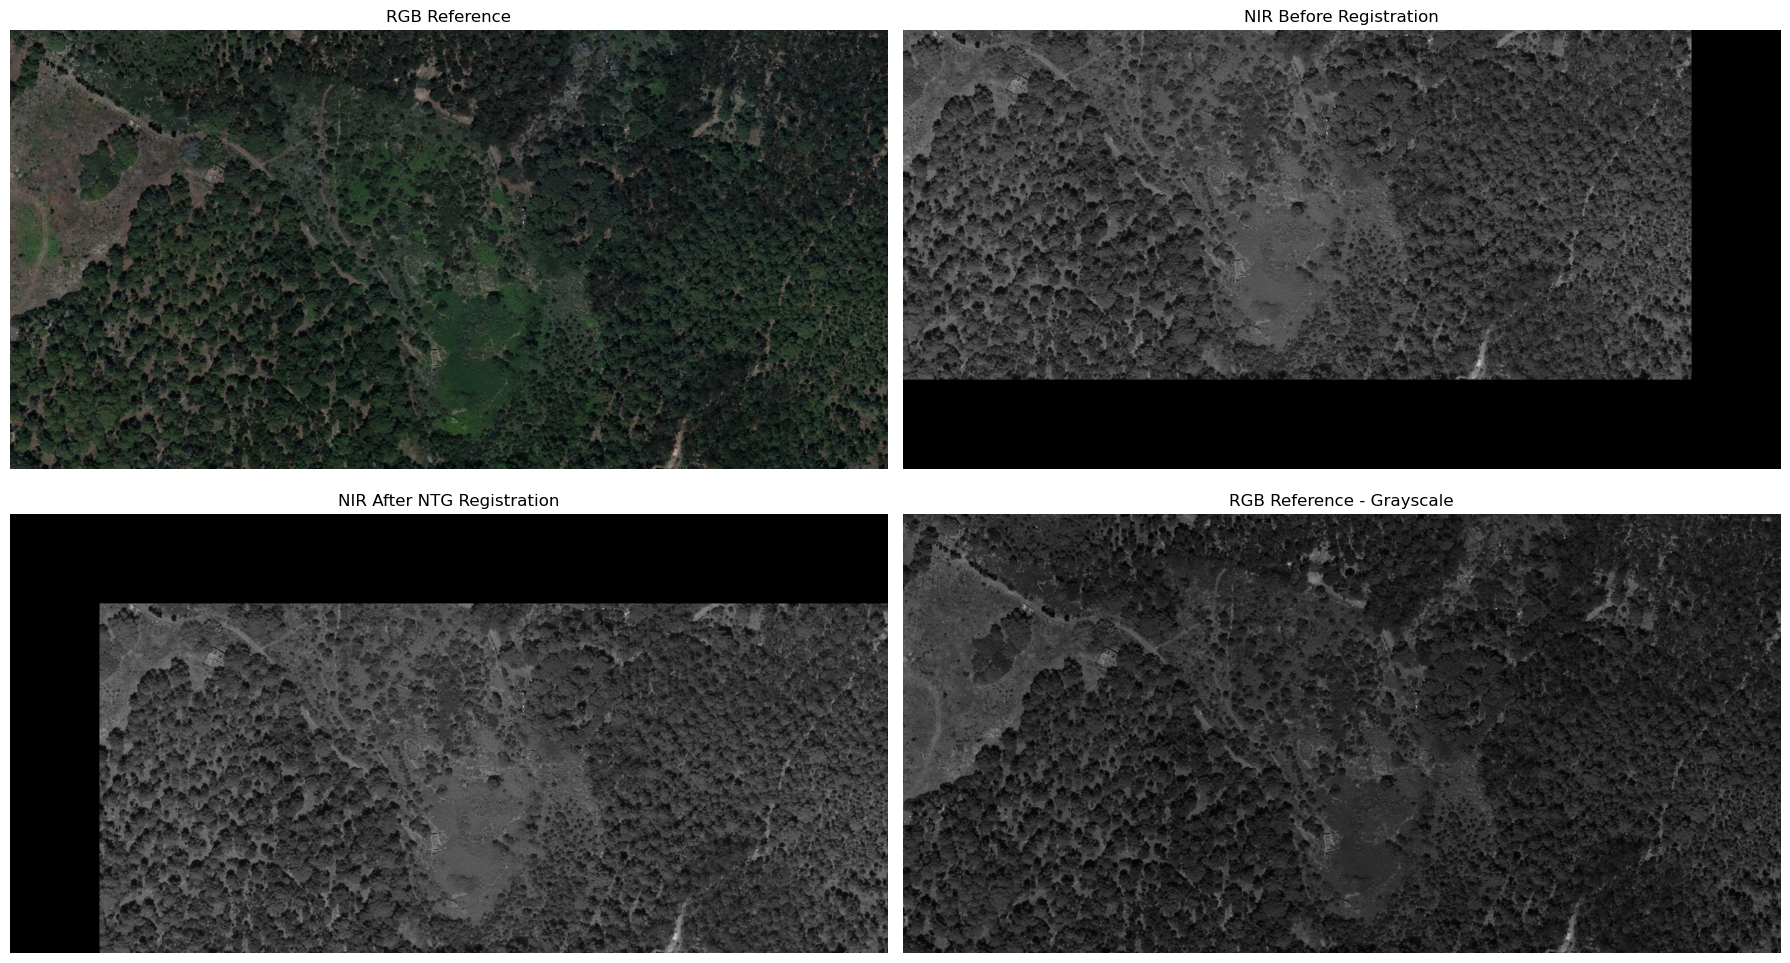

In [35]:
plt.figure(figsize=(18, 10))

# ------------------------------------------------------------
# RGB
# ------------------------------------------------------------

plt.subplot(2, 2, 1)

plt.imshow(rgb_ref)

plt.title(
    "RGB Reference"
)

plt.axis("off")


# ------------------------------------------------------------
# NIR desplazada
# ------------------------------------------------------------

plt.subplot(2, 2, 2)

plt.imshow(
    nir_before,
    cmap="gray"
)

plt.title(
    "NIR Before Registration"
)

plt.axis("off")


# ------------------------------------------------------------
# NIR registrada
# ------------------------------------------------------------

plt.subplot(2, 2, 3)

plt.imshow(
    nir_after,
    cmap="gray"
)

plt.title(
    "NIR After NTG Registration"
)

plt.axis("off")


# ------------------------------------------------------------
# RGB grayscale
# ------------------------------------------------------------

plt.subplot(2, 2, 4)

plt.imshow(
    rgb_gray_ref,
    cmap="gray"
)

plt.title(
    "RGB Reference - Grayscale"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [36]:
def normalize_visual(img):

    img = img.astype(np.float32)

    min_val = np.min(img)
    max_val = np.max(img)

    return (
        img - min_val
    ) / (
        max_val - min_val + 1e-8
    )

In [37]:
rgb_vis = normalize_visual(
    rgb_gray_ref
)

nir_before_vis = normalize_visual(
    nir_before
)

nir_after_vis = normalize_visual(
    nir_after
)

In [38]:
# ============================================================
# FALSE-COLOR OVERLAY
#
# RED   = RGB
# GREEN = NIR
#
# Si las estructuras coinciden espacialmente,
# los bordes rojo/verde se superponen.
# ============================================================

overlay_before = np.zeros(
    (
        rgb_vis.shape[0],
        rgb_vis.shape[1],
        3
    ),
    dtype=np.float32
)

overlay_after = np.zeros_like(
    overlay_before
)


# BEFORE
overlay_before[:, :, 0] = rgb_vis
overlay_before[:, :, 1] = nir_before_vis


# AFTER
overlay_after[:, :, 0] = rgb_vis
overlay_after[:, :, 1] = nir_after_vis

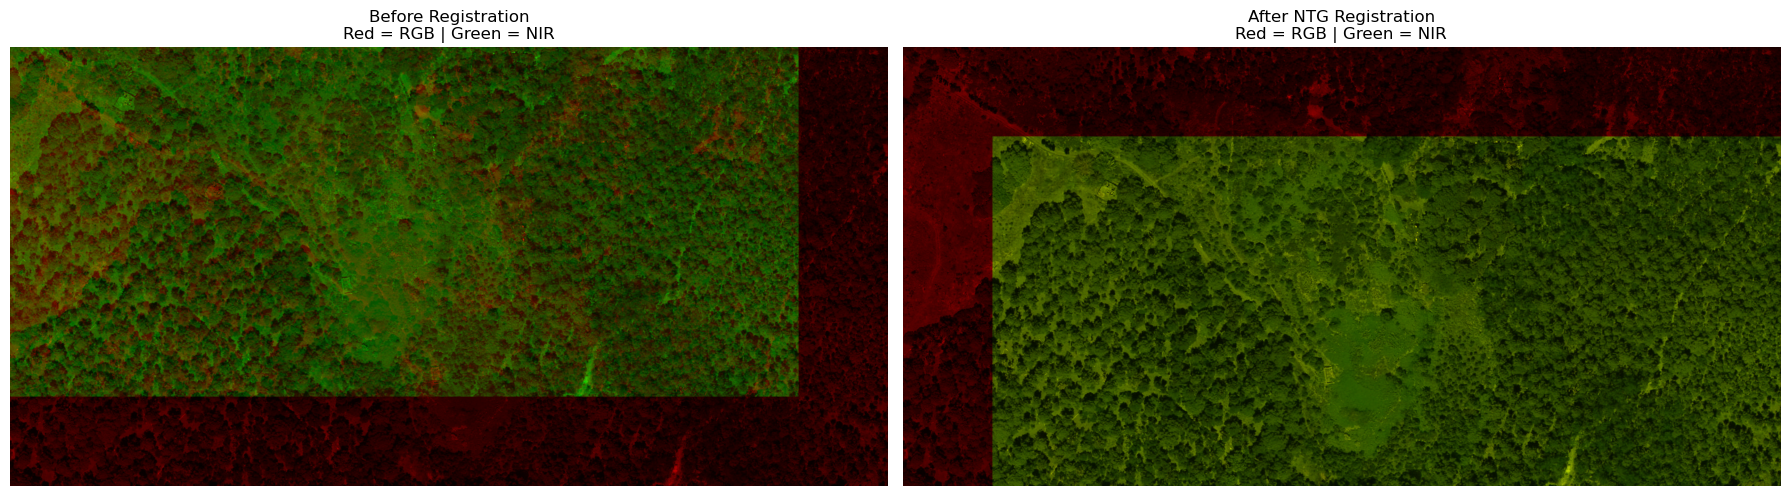

In [39]:
# ============================================================
# FALSE-COLOR OVERLAY
#
# RED   = RGB
# GREEN = NIR
#
# Si las estructuras coinciden espacialmente,
# los bordes rojo/verde se superponen.
# ============================================================

overlay_before = np.zeros(
    (
        rgb_vis.shape[0],
        rgb_vis.shape[1],
        3
    ),
    dtype=np.float32
)

overlay_after = np.zeros_like(
    overlay_before
)


# BEFORE
overlay_before[:, :, 0] = rgb_vis
overlay_before[:, :, 1] = nir_before_vis


# AFTER
overlay_after[:, :, 0] = rgb_vis
overlay_after[:, :, 1] = nir_after_vis

plt.figure(figsize=(18, 8))


plt.subplot(1, 2, 1)

plt.imshow(
    overlay_before
)

plt.title(
    "Before Registration\n"
    "Red = RGB | Green = NIR"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    overlay_after
)

plt.title(
    "After NTG Registration\n"
    "Red = RGB | Green = NIR"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [40]:
for item in history:

    print(
        f"Level {item['level']}: "
        f"{item['parameters']}"
    )

Level 0: [ 1.00071595e+00  8.03992184e-06 -2.50248690e+01 -3.43202516e-06
  1.00201304e+00 -2.50517367e+01]
Level 1: [ 1.0007160e+00  8.0399222e-06 -5.0049740e+01 -3.4320251e-06
  1.0020131e+00 -5.0103474e+01]
Level 2: [ 1.0007160e+00  8.0399222e-06 -1.0009948e+02 -3.4320251e-06
  1.0020131e+00 -1.0020695e+02]
Level 3: [ 1.0007160e+00  8.0399222e-06 -2.0019896e+02 -3.4320251e-06
  1.0020131e+00 -2.0041389e+02]
